In [1]:
# Written by David Schneidinger. Please modify as needed. Email me dschneidinger@g.ucla.edu if you have any questions
%load_ext autoreload
%autoreload 2

from analysis_utils import MagShockZRun
import astropy.units as u
import astropy.constants
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import osiris_utils
sim = osiris_utils.Simulation("/pscratch/sd/d/dschnei/perlmutter_1.2.1d/testing_writeout.txt")

In [6]:
input_deck = "/pscratch/sd/d/dschnei/perlmutter_1.2.1d/testing_writeout.txt"
Z = 6
m_i = 26.981 * astropy.constants.m_p
B0 = 100_000 * astropy.units.Gauss
n0 = 5e18 * u.cm**-3
T_e = 40 * astropy.units.eV
sim = MagShockZRun(input_deck = input_deck, norm_density = n0, B0 = B0, Z=Z, m_i=m_i)

# Calculate some relevant plasma quantities (hopefully in a generalized way)

In [7]:
wpe = sim.omega_p_real
rqm = sim.rqm
# omega_ci_real = sim.omega_ci_real(B_real = B0, Z=Z, m_i = m_i)
ion_plasma_frequency_real = sim.omega_pi_real(Z = Z, m_i = m_i)
ion_inertial_length_real = sim.ion_inertial_length_real(Z=Z, m_i=m_i)
electron_inertial_length_real = sim.electron_inertial_length_real()
B_osiris = sim.B_osiris()
debye_length_real = sim.lambda_D_real(T_e)
debye_length = sim.lambda_D(T_e)
alfven_speed_real = sim.vA_real()

print(f"plasma frequency (real): {np.format_float_scientific(wpe.value,2)} rad/s")
print(f"ion inertial length (real): {np.format_float_scientific(ion_inertial_length_real.value,2)} cm")
print(f"electron inertial length (real): {np.format_float_scientific(electron_inertial_length_real.value,2)} cm")
print(f"Debye length (real): {np.format_float_scientific(debye_length_real.value,2)} cm")
print(f"ion sound speed (real): {np.format_float_scientific(sim.ion_sound_speed_real(T_e).value,2)}")
print(f"Debye length (normalized): {np.format_float_scientific(debye_length.value,2)}")
print(f"Magnetic field (normalized): {np.format_float_scientific(B_osiris.value,2)}")
print(f"ion cyclotron frequency (real): {np.format_float_scientific(sim.omega_ci_real(B_real=B0, Z=Z, m_i=m_i).value,2)} rad/s")

plasma frequency (real): 1.26e+14 rad/s
ion inertial length (real): 2.16e-02 cm
electron inertial length (real): 2.38e-04 cm
Debye length (real): 2.10e-06 cm
ion sound speed (real): 3.77e+06
Debye length (normalized): 8.85e-03
Magnetic field (normalized): 1.39e-02
ion cyclotron frequency (real): 2.13e+08 rad/s


<Axes: title={'center': 'b3-savg at t = 0.109 $[\\omega_{ci}^{-1}]$'}, xlabel='$x [c/\\omega_{pi}]$', ylabel='b3-savg'>

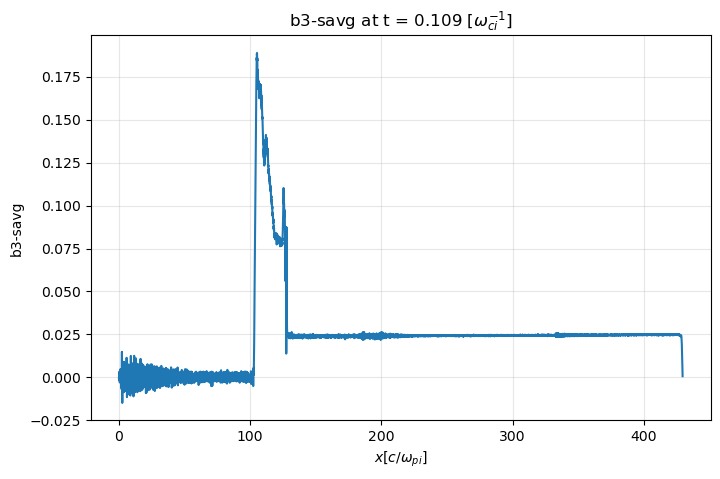

In [14]:
sim.plot('b3-savg',t=17)

In [58]:
sim.add_moment("al", p = "p1", order = 2)

RuntimeError: Error loading data at index 0

In [26]:
sim.add_moment_diagnostic('al', 'p2', order=2)
sim.add_moment_diagnostic('e', 'p2', order=2)
sim.add_moment_diagnostic('si', 'p2', order=2)
sim.plot_field('al/vth2-from-p2', timestep=150)
sim.plot_lineout('al/vth2-from-p2', timestep=150, axis='x', position=0)

sim.add_moment_diagnostic('al', 'p1', order=1)
sim.add_moment_diagnostic('al', 'p1', order=2)

AttributeError: 'dict' object has no attribute 'diags'

In [27]:
al_vth2_from_p2 = sim._get_field('al/vth2-from-p2')
e_vth2_from_p2 = sim._get_field('e/vth2-from-p2')
si_vth2_from_p2 = sim._get_field('si/vth2-from-p2')
t = 15
np.shape(al_vth2_from_p2[0])
T_e = (e_vth2_from_p2[t] * astropy.constants.m_e * astropy.constants.c**2).to(u.eV)
T_al = (al_vth2_from_p2[t] * sim.rqm * astropy.constants.m_e * astropy.constants.c**2).to(u.eV)
T_si = (si_vth2_from_p2[t] * 38 * astropy.constants.m_e * astropy.constants.c**2).to(u.eV)
plt.semilogy(T_e[:,0], label= r'$T_e$')
plt.semilogy(T_al[:,0], label= r'$T_{al}$')
plt.semilogy(T_si[:,0], label= r'$T_{si}$')
plt.ylabel('Temperature (eV)')
plt.xlabel('y (a.u.)')
plt.title(f'Temperature lineout at x=0, t={sim["b3-savg"].time(t)[0]}' + rf'${sim["b3-savg"].time(t)[1]}$')
plt.legend()
plt.show()
# Plot temperature ratios
T_ratio = T_e[:,0] / T_al[:,0]
plt.semilogy(T_ratio, label=r'$T_e / T_{al}$')
plt.ylabel('Temperature Ratio')
plt.title(f'Te/Ti lineout at x=0, t={round(sim["b3-savg"].time(t)[0] * sim.omega_ci(),3)}' + r'$\omega_{ci}$')
plt.ylim(1e-2,1e2)

AttributeError: 'dict' object has no attribute 'diags'

## According to the first plot, there is a HUGE temperature difference between electrons and ions, but then it seems to equilibrate at later times.

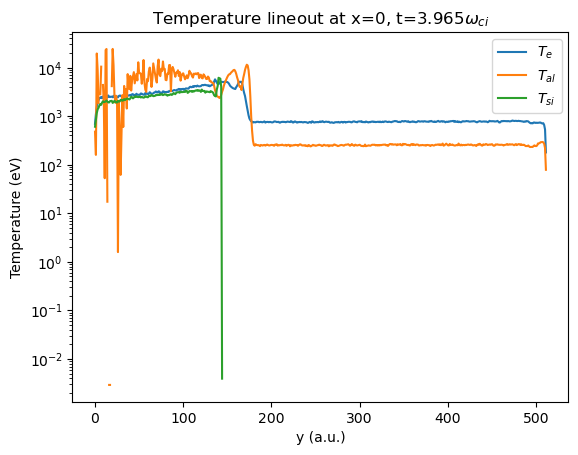

(0.01, 100.0)

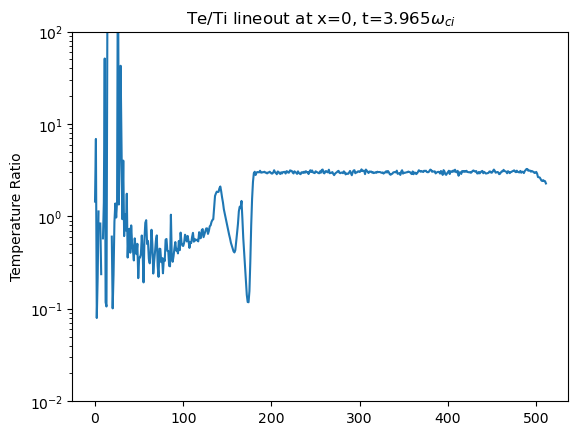

In [9]:
t = 100
np.shape(al_vth2_from_p2[0])
T_al = (al_vth2_from_p2[t] * sim.rqm * astropy.constants.m_e * astropy.constants.c**2).to(u.eV)
T_e = (e_vth2_from_p2[t] * astropy.constants.m_e * astropy.constants.c**2).to(u.eV)
T_si = (si_vth2_from_p2[t] * 38 * astropy.constants.m_e * astropy.constants.c**2).to(u.eV)
plt.semilogy(T_e[:,0], label= r'$T_e$')
plt.semilogy(T_al[:,0], label= r'$T_{al}$')
plt.semilogy(T_si[:,0], label= r'$T_{si}$')
plt.ylabel('Temperature (eV)')
plt.xlabel('y (a.u.)')
plt.title(f'Temperature lineout at x=0, t={round(sim["b3-savg"].time(t)[0] * sim.omega_ci(),3)}' + r'$\omega_{ci}$')
plt.legend()
plt.show()
# Plot temperature ratios
T_ratio = T_e[:,0] / T_al[:,0]
plt.semilogy(T_ratio, label=r'$T_e / T_{al}$')
plt.ylabel('Temperature Ratio')
plt.title(f'Te/Ti lineout at x=0, t={round(sim["b3-savg"].time(t)[0] * sim.omega_ci(),3)}' + r'$\omega_{ci}$')
plt.ylim(1e-2,1e2)

# Let's start by generating some rudimentary plots from the simulation

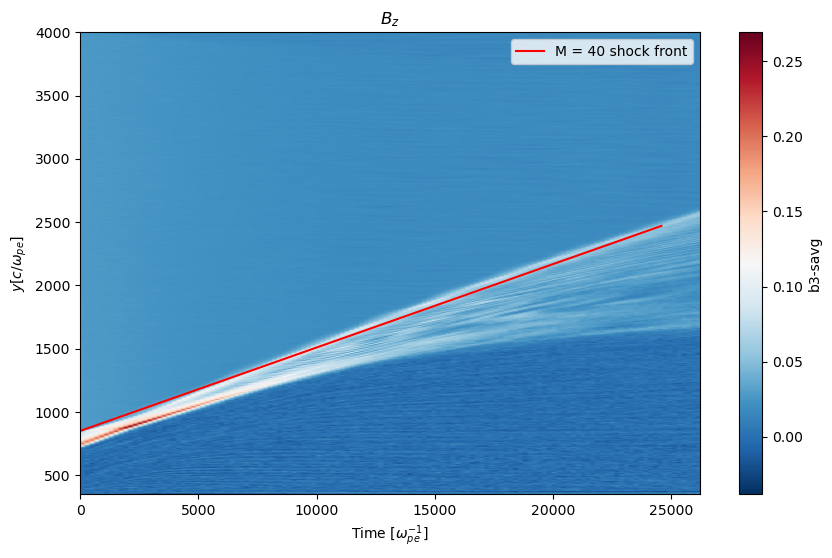

In [ ]:
sim.plot_streak('b3-savg',axis='y', time_units='electron',spatial_units = 'electron')
times = np.linspace(sim['b3-savg'].time(0)[0],sim['b3-savg'].time(120)[0],100)
M = 40
magnetosonic_speed = np.sqrt(sim.vA()**2 + sim.ion_sound_speed_real(40 * u.eV)**2 / astropy.constants.c**2)
shock_front = 850 + M * magnetosonic_speed * times
plt.plot(times, shock_front, color = 'red', label = f"M = {M} shock front")
plt.title(r"$B_z$")
plt.legend()
plt.show()

Text(0.5, 0, 'y (a.u.)')

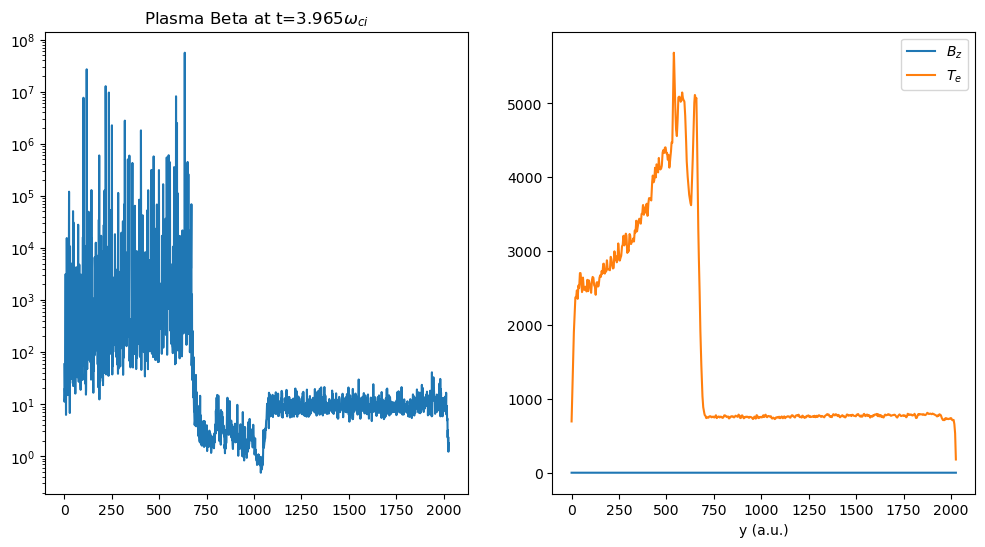

In [38]:
# Calculate the plasma beta at every localized point in space
# beta = n k_B T / (B^2 / (2 mu_0))
# We can use the temperature from the moment diagnostics and the magnetic field from the field diagnostics to calculate the plasma beta
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))

t = 100
# print(sim['b3-savg'].grid)
# print(sim['b3-savg'].nx)
xnew = np.linspace(sim['b3-savg'].grid[1][0], 
                   sim['b3-savg'].grid[1][1], 
                   sim['b3-savg'].nx[1])
# print(np.shape(xnew))
xold = np.linspace(sim['e']['p1x1x2'].grid[0][0], 
                   sim['e']['p1x1x2'].grid[0][1], 
                   sim['e']['p1x1x2'].nx[0])
# print(np.shape(xold))
# print(xold)
T_e = (e_vth2_from_p2[t] * astropy.constants.m_e * astropy.constants.c**2).to(u.eV)
T_e_new = np.interp(xnew, xold, T_e[:,0])

def beta(n: (astropy.units.cm**-3), T: astropy.units.eV, B: astropy.units.Gauss):
    beta = n * T / (B**2 / (2 * astropy.constants.mu0))
    return beta.to(u.dimensionless_unscaled)
beta_e = beta(n0, T_e_new, sim['b3-savg'][t][np.shape(sim['b3-savg'][t])[0]//2,:]* 3.204e-3 * np.sqrt(n0 * u.cm**3) * u.Gauss)
ax1.semilogy(beta_e, label=r'$\beta_e$')
ax1.set_title(f'Plasma Beta at t={round(sim["b3-savg"].time(t)[0] * sim.omega_ci(),3)}' + r'$\omega_{ci}$')

ax2.plot(sim['b3-savg'][t][np.shape(sim['b3-savg'][t])[0]//2,:], label=r'$B_z$')
ax2.plot(T_e_new, label=r'$T_e$')
# sim.plot_lineout('b3-savg', timestep=t, axis='y', label=r'$B_z$')
ax2.legend()
plt.xlabel('y (a.u.)')

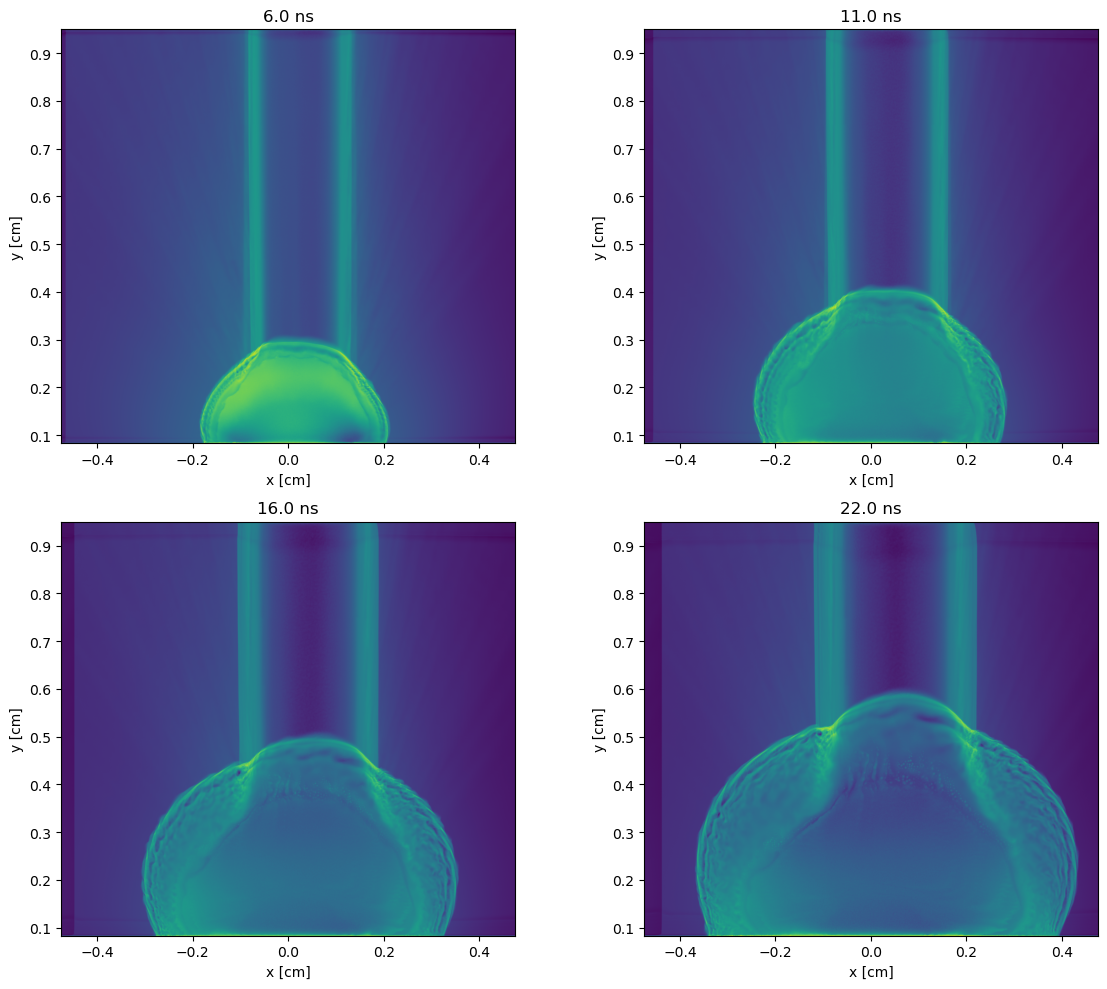

In [ ]:
# At t = 0, things should look pretty identical to how they are initialized from FLASH
def plot_with_zoom(data, t, xmin_zoom, xmax_zoom, ymin_zoom, ymax_zoom, zoom = True):
    # Create figure and main axes
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(np.log(-1*data[t].T), origin='lower', extent=[xmin *electron_inertial_length_real, xmax * electron_inertial_length_real, 
                                                        ymin * electron_inertial_length_real, ymax * electron_inertial_length_real],)
                #    vmax=np.max(np.log(data[t]))/1.5)
    ax.set_xlabel(r"x [cm]")
    ax.set_ylabel(r"y [cm]")
    plt.title(rf"${data.name}$" + f", t = {np.round((data.time(t)[0] * omega_ci /omega_ci_real).to(astropy.units.ns).value, 3)} ns")
    # plt.title(f"t = {round(data.time(t)[0] * omega_ci,0)}" + r"$\Omega_{ci}$")
    if zoom:
        # Create inset axes (adjust position and size as needed)
        # Parameters: [width%, height%, location] where location can be 1-4 or 'upper right', 'lower left', etc.
        axins = inset_axes(ax, width="40%", height="40%", loc='upper right')
        
        # Plot the same data in the inset
        axins.imshow(np.log(-1 * data[t].T), origin='lower', extent=[xmin * electron_inertial_length_real, xmax * electron_inertial_length_real,
                                                        ymin *electron_inertial_length_real, ymax * electron_inertial_length_real])
        
        # Set the zoom region (adjust these values to your region of interest)
        x1, x2 = xmin_zoom, xmax_zoom  # zoom to left half
        y1, y2 = ymin_zoom, ymax_zoom  # zoom to bottom half
        axins.set_xlim(x1, x2)
        axins.set_ylim(y1, y2)
        
        # Optional: mark the inset region on the main plot with a rectangle and connecting lines
        mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="white", lw=1.5, linestyle='--')
        axins.set_xticks([])
        axins.set_yticks([])
    
    # plt.tight_layout()
    plt.show()
times = [30, 60, 87, 116]
data = sim['e']['charge-savg']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, t in zip(axes.flat, times):
    im = ax.imshow(
        np.log(-1 * data[t].T),
        origin='lower',
        extent=[
            xmin * electron_inertial_length_real,
            xmax * electron_inertial_length_real,
            ymin * electron_inertial_length_real,
            ymax * electron_inertial_length_real,
        ],
    )
    ax.set_title(
        f"{np.round((data.time(t)[0] * omega_ci / omega_ci_real).to(astropy.units.ns).value, 0)} ns"
    )
    ax.set_xlabel(r"x [cm]")
    ax.set_ylabel(r"y [cm]")

plt.tight_layout()
# plt.suptitle("electron charge density")
plt.show()


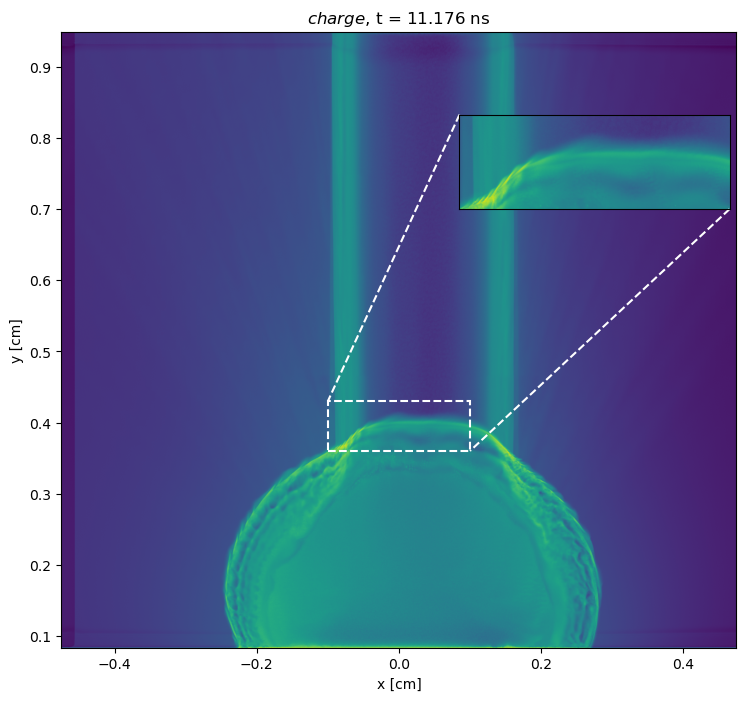

In [ ]:
plot_with_zoom(sim['e']['charge-savg'], t=60, xmin_zoom=-0.1, xmax_zoom=0.1, ymin_zoom = .36, ymax_zoom=.43, zoom=True)

In [ ]:
# Generalized function for any diagnostic quantity
def plot_yt_evolution(diagnostic, x_index=None, vmin=None, vmax=None, 
                      cmap='RdBu_r', title=None):
    """
    Plot time evolution along y-axis for any diagnostic.
    
    Parameters:
    -----------
    diagnostic : osiris_utils diagnostic
        The diagnostic to plot (e.g., sim['b1-savg'])
    x_index : int, optional
        X-position index for lineout (default: center)
    vmin, vmax : float, optional
        Color scale limits
    cmap : str
        Colormap name
    title : str, optional
        Plot title
    """
    # Get number of time steps
    n_times = len(diagnostic)
    
    # Default to center if x_index not specified
    if x_index is None:
        x_index = diagnostic[0].shape[0] // 2
    
    # Extract lineouts
    lineouts = np.array([diagnostic[t][x_index, :] for t in range(n_times)])
    
    # Get time axis
    times_array = np.array([diagnostic.time(t)[0] for t in range(n_times)])
    times_ns = (times_array * omega_ci / omega_ci_real).to(astropy.units.ns).value
    
    # Get y-axis
    y_positions = np.linspace(ymin * electron_inertial_length_real, 
                              ymax * electron_inertial_length_real, 
                              lineouts.shape[1])
    
    # Create plot
    fig, ax = plt.subplots(figsize=(14, 8))
    
    im = ax.imshow(lineouts.T, aspect='auto', origin='lower',
                   extent=[times_ns.min(), times_ns.max(), 
                          y_positions.min(), y_positions.max()],
                   cmap=cmap, vmin=vmin, vmax=vmax)
    
    ax.set_xlabel('Time [ns]')
    ax.set_ylabel('y position [cm]')
    
    if title is None:
        title = f'{diagnostic.name} evolution along y-axis'
    ax.set_title(title)
    
    cbar = plt.colorbar(im, ax=ax, label=diagnostic.name)
    
    plt.tight_layout()
    plt.show()
    
    return times_ns, y_positions, lineouts

# Example usage
times_ns, y_pos, data = plot_yt_evolution(sim['b1-savg'], title=r'$B_x$ (savg) evolution')

In [ ]:
# Try with other quantities for comparison
# Example: electron density
try:
    plot_yt_evolution(sim['e']['charge'], cmap='viridis', 
                     title='Electron density evolution')
except Exception as e:
    print(f"Could not plot electron density: {e}")

# Example: Other magnetic field components
try:
    plot_yt_evolution(sim['b2-savg'], cmap='RdBu_r',
                     title=r'$B_y$ (savg) evolution')
except Exception as e:
    print(f"Could not plot b2-savg: {e}")

# Example: Electric field
try:
    plot_yt_evolution(sim['e1-savg'], cmap='RdBu_r',
                     title=r'$E_x$ (savg) evolution')
except Exception as e:
    print(f"Could not plot e1-savg: {e}")